# Basin Hierarchy: Diagnostics & Deliverables for Alexis

Merged from `building_hucs_nested_basins.ipynb` and `basin_hierarchy_for_ale.ipynb`.

**Runs AFTER `03_all_chile_glacier_streamflow_v3.ipynb`** — this notebook depends
on `RESULTS.pkl` and `spatial_join_nested.csv`, both produced there. It is not
part of the core numbered pipeline (01/02/03); think of it as an appendix
notebook for basin-hierarchy diagnostics and Alexis-facing deliverables.

Hierarchy (nesting depth, top-level/"main" basins) is computed via
`basin_hierarchy_utils.py` (geometric polygon containment) rather than the
`Camels_jerarquia.shp` `jerarquia` field, which was found to be a constant 0
across all 146 basins in that file — including basins that are clearly nested
(e.g. Rio Maipo En El Manzano is 100% contained within Rio Maipo En Cabimbao,
both labeled `jerarquia=0`). Source ArcGIS metadata suggests this field was
likely never populated with real values, rather than corrupted downstream.
Alexis has been asked directly whether this field was ever meant to carry
real hierarchy levels.

## Sections
1. Setup & load
2. Compute basin hierarchy (shared module — single source of truth)
3. Leaf-level & major-basin identification
4. Data quality: glacier region coverage, anomalous gauges, runoff>Q by depth
5. Dilution visualization (glacier fraction vs. position in hierarchy)
6. Leaf-summed glacier fraction per major basin (annual / JFM / megadrought)
7. Deliverables for Alexis: `main_basins_for_alexis.shp` export + maps


## 1. Setup & load

In [1]:
import os, sys, pickle, calendar
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Wedge
from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from oggm import utils
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/Users/milliespencer/OGGM_CR2_Chile')
from basin_hierarchy_utils import compute_basin_hierarchy, build_containment_maps, get_full_chain
from completeness_utils import assess_completeness, LAT_BOUNDARY

BASE_PATH   = '/Users/milliespencer/Desktop/CR2_OGGM_Paper'
CAMELS_FULL = f'{BASE_PATH}/Full_CAMELS_all_basins/CAMELS_CL_v202201'
BOUNDS_PATH = f'{CAMELS_FULL}/camels_cl_boundaries/camels_cl_boundaries.shp'
OUTPUT_ROOT = f'{BASE_PATH}/Output'
OUT_DIR_SUB = f'{OUTPUT_ROOT}/all_chile_results_v2'
NESTED_CSV_PATH = f'{OUT_DIR_SUB}/spatial_join_nested.csv'
RGI_PATH    = f'{BASE_PATH}/files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv'

print(f'Bounds shapefile exists: {os.path.exists(BOUNDS_PATH)}')
print(f'RESULTS.pkl exists: {os.path.exists(f"{OUT_DIR_SUB}/RESULTS.pkl")}')


/Users/milliespencer/miniconda3/envs/oggm_cr2_env/lib/python3.11/site-packages/oggm/__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Bounds shapefile exists: True
RESULTS.pkl exists: True


In [2]:
# ── Load basins, glacier area, RESULTS, country borders ────────────────────
with open(f'{OUT_DIR_SUB}/RESULTS.pkl', 'rb') as f:
    RESULTS = pickle.load(f)
print(f'RESULTS loaded: {len(RESULTS["CR2MET"])} gauges (CR2MET)')

bounds_all = gpd.read_file(BOUNDS_PATH).to_crs(epsg=4326)
bounds_all['gauge_id'] = bounds_all['gauge_id'].astype(str)

nested_csv = pd.read_csv(NESTED_CSV_PATH, dtype={'gauge_id': str})
glacier_area_by_gauge = nested_csv.groupby('gauge_id')['Area'].sum().to_dict()
all_glacierized_basins_ever = set(
    gid for gid, area in glacier_area_by_gauge.items() if area > 0)

rgi_bna = pd.read_csv(RGI_PATH)
gdf_rgi = gpd.GeoDataFrame(
    rgi_bna, geometry=gpd.points_from_xy(rgi_bna.CenLon, rgi_bna.CenLat), crs='EPSG:4326')

try:
    world = gpd.read_file(
        'https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip')
    chile = world[world['NAME'] == 'Chile']
    arg = world[world['NAME'] == 'Argentina']
    has_borders = True
except Exception as e:
    print(f'Could not load country borders: {e}')
    has_borders = False

print(f'Basins loaded: {len(bounds_all)}')
print(f'Glacierized basins nationally: {len(all_glacierized_basins_ever)}')


RESULTS loaded: 143 gauges (CR2MET)
Basins loaded: 516
Glacierized basins nationally: 266


## 2. Compute basin hierarchy (shared module)

Single source of truth: `basin_hierarchy_utils.py`. This replaces the raw
O(n^2) containment loops that were previously duplicated across this
notebook and `02_glacier_to_basin_script.ipynb`, and replaces reliance on
`Camels_jerarquia.shp` entirely.

In [3]:
bounds_utm = bounds_all.to_crs(epsg=32719)
area_by_id = dict(zip(bounds_utm['gauge_id'], bounds_utm.geometry.area.values))

# contained_map[gid]  -> list of gauge_ids that gid CONTAINS (gid is parent)
# container_map[gid]  -> list of gauge_ids that CONTAIN gid (gid is child)
contained_map, container_map = build_containment_maps(bounds_utm)  # all 516 basins
print(f'Containment maps built for {len(bounds_all)} basins')

df_hierarchy = compute_basin_hierarchy(bounds_all)  # depth / immediate_parent / major_basin
df_hierarchy.to_csv(f'{OUTPUT_ROOT}/basin_hierarchy_full.csv', index=False)

print('\nNesting depth distribution (0 = top-level/major basin):')
print(df_hierarchy['depth'].value_counts().sort_index())
print(f'\nMax nesting depth found: {df_hierarchy["depth"].max()}')
print(f'Saved: {OUTPUT_ROOT}/basin_hierarchy_full.csv')


Containment maps built for 516 basins

Nesting depth distribution (0 = top-level/major basin):
depth
0     101
1     108
2      95
3      75
4      45
5      33
6      18
7      16
8      12
9       6
10      4
11      1
12      1
13      1
Name: count, dtype: int64

Max nesting depth found: 13
Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/basin_hierarchy_full.csv


## 3. Leaf-level & major-basin identification

In [4]:
# ── Top-level ("major") basins, and which of them contain glaciers ─────────
df_top_level = df_hierarchy[df_hierarchy['depth'] == 0].copy()
df_top_level['contained_gauge_ids'] = df_top_level['gauge_id'].map(
    lambda g: contained_map.get(g, []))
df_top_level['n_nested_basins'] = df_top_level['contained_gauge_ids'].apply(len)

records = []
for _, row in df_top_level.iterrows():
    major_id = row['gauge_id']
    nested_ids = row['contained_gauge_ids']
    total_glacier_area = (glacier_area_by_gauge.get(major_id, 0) +
                          sum(glacier_area_by_gauge.get(nid, 0) for nid in nested_ids))
    n_glacierized_nested = sum(1 for nid in nested_ids
                               if glacier_area_by_gauge.get(nid, 0) > 0)
    if total_glacier_area > 0:
        records.append({
            'gauge_id': major_id, 'gauge_name': row['gauge_name'],
            'area_km2': row['area_km2'], 'n_nested_basins': row['n_nested_basins'],
            'n_glacierized_nested': n_glacierized_nested,
            'total_glacier_area_km2': total_glacier_area,
        })
df_glacierized_major = pd.DataFrame(records).sort_values(
    'total_glacier_area_km2', ascending=False)

# ── Leaf-level glacierized basins: a basin qualifies if NONE of its
# contained sub-basins is ALSO glacierized (avoids double-counting) ────────
leaf_glacierized_ids_v3 = set()
for gid in all_glacierized_basins_ever:
    glacierized_children = [c for c in contained_map.get(gid, [])
                             if glacier_area_by_gauge.get(c, 0) > 0]
    if len(glacierized_children) == 0:
        leaf_glacierized_ids_v3.add(gid)

print(f'Top-level basins: {len(df_top_level)}')
print(f'Top-level basins containing glaciers: {len(df_glacierized_major)}')
print(f'Leaf-level glacierized basins: {len(leaf_glacierized_ids_v3)}')


Top-level basins: 101
Top-level basins containing glaciers: 41
Leaf-level glacierized basins: 103


In [5]:
# ── Known gauge-coverage gap: glaciers here can't be assigned to any
# streamflow basin and are excluded from all streamflow-fraction analyses ──
gap_glaciers = rgi_bna[(rgi_bna['CenLat'] <= -23) & (rgi_bna['CenLat'] >= -27)]
print(f'Glaciers in the -23 to -27 gauge-coverage gap: {len(gap_glaciers)}')
print(f'Total area: {gap_glaciers["Area"].sum():.2f} km2')


Glaciers in the -23 to -27 gauge-coverage gap: 65
Total area: 18.14 km2


## 4. Data quality: glacier region coverage, anomalous gauges, runoff>Q by depth

In [6]:
# ── Combined glacier polygons, RGI regions 16+17 ────────────────────────────
# Region 16 must be included or 32 glaciers physically inside Chile
# (29 of which are part of the OGGM pipeline via RGI_BNA_Clusters.csv)
# are silently excluded.
rgi_r17_path = utils.get_rgi_region_file('17', version='62')
rgi_r16_path = utils.get_rgi_region_file('16', version='62')
rgi_r17 = gpd.read_file(rgi_r17_path).to_crs(epsg=4326)
rgi_r16 = gpd.read_file(rgi_r16_path).to_crs(epsg=4326)
rgi_r16_chile = gpd.clip(rgi_r16, chile) if has_borders else rgi_r16
rgi_geoms_combined = pd.concat([rgi_r17, rgi_r16_chile], ignore_index=True)

print(f'Region 17: {len(rgi_r17)} glaciers')
print(f'Region 16 (clipped to Chile): {len(rgi_r16_chile)} glaciers')
print(f'Combined: {len(rgi_geoms_combined)} glaciers')


Region 17: 15908 glaciers
Region 16 (clipped to Chile): 32 glaciers
Combined: 15940 glaciers


In [7]:
# ── Data quality flagging: basins where simulated glacier runoff exceeds
# measured streamflow in a large fraction of months ─────────────────────────
def check_runoff_exceeds_q(gid, dataset='CR2MET'):
    res = RESULTS[dataset].get(gid)
    if res is None:
        return None
    m = res['monthly'].copy()
    m = m[m['q_m3_mon'] > 0].dropna(subset=['glacier_runoff_m3','q_m3_mon'])
    if len(m) == 0:
        return None
    m['pct'] = m['glacier_runoff_m3'] / m['q_m3_mon'] * 100
    return {
        'n_months': len(m),
        'n_months_over_100': (m['pct'] > 100).sum(),
        'pct_months_over_100': (m['pct'] > 100).mean() * 100,
        'median_pct': m['pct'].median(),
        'max_pct': m['pct'].max(),
    }

name_by_id = df_hierarchy.set_index('gauge_id')['gauge_name'].to_dict()
quality_records = []
for gid in all_glacierized_basins_ever:
    if gid not in RESULTS['CR2MET']:
        continue
    result = check_runoff_exceeds_q(gid)
    if result is None:
        continue
    quality_records.append({'gauge_id': gid, 'gauge_name': name_by_id.get(gid, '?'), **result})

df_quality = pd.DataFrame(quality_records).sort_values('pct_months_over_100', ascending=False)

QUALITY_FLAG_THRESHOLD = 20.0
flagged_basins = set(
    df_quality[df_quality['pct_months_over_100'] > QUALITY_FLAG_THRESHOLD]['gauge_id'])
print(f'Basins flagged (>{QUALITY_FLAG_THRESHOLD}% of months with runoff>Q): {len(flagged_basins)}')
df_quality.to_csv(f'{OUTPUT_ROOT}/basin_data_quality_flags.csv', index=False)
print(df_quality.head(15).to_string(index=False))


Basins flagged (>20.0% of months with runoff>Q): 9
gauge_id                                  gauge_name  n_months  n_months_over_100  pct_months_over_100   median_pct      max_pct
 7317003                 Rio Melado En Zona De Presa       199                107            53.768844 2.154615e+02 69191.958960
 5406001                    Rio Colorado En Colorado       206                 87            42.233010 5.675125e+01 27263.759403
 6008005    Rio Cachapoal En Pte Termas De Cauquenes       190                 65            34.210526 6.519751e+01  2603.588778
 7321002                      Rio Maule En Armerillo       197                 65            32.994924 1.324780e+01   849.418806
 7306001 Rio Cipreses En Dasague Laguna La Invernada       172                 48            27.906977 8.594820e+00   353.659743
 5706001       Rio Olivares Antes Junta Rio Colorado       222                 59            26.576577 6.590002e+00   991.761563
 3022001                     Rio La Ola En Ver

Data quality reliability by nesting depth:
 depth  n_basins_total  n_glacierized  n_flagged  pct_flagged
     0             101             41          1     2.439024
     1             108             51          2     3.921569
     2              95             49          1     2.040816
     3              75             40          2     5.000000
     4              45             27          1     3.703704
     5              33             19          0     0.000000
     6              18             12          2    16.666667
     7              16              9          0     0.000000
     8              12              8          0     0.000000
     9               6              5          0     0.000000
    10               4              3          0     0.000000
    11               1              1          0     0.000000
    12               1              1          0     0.000000
    13               1              0          0          NaN


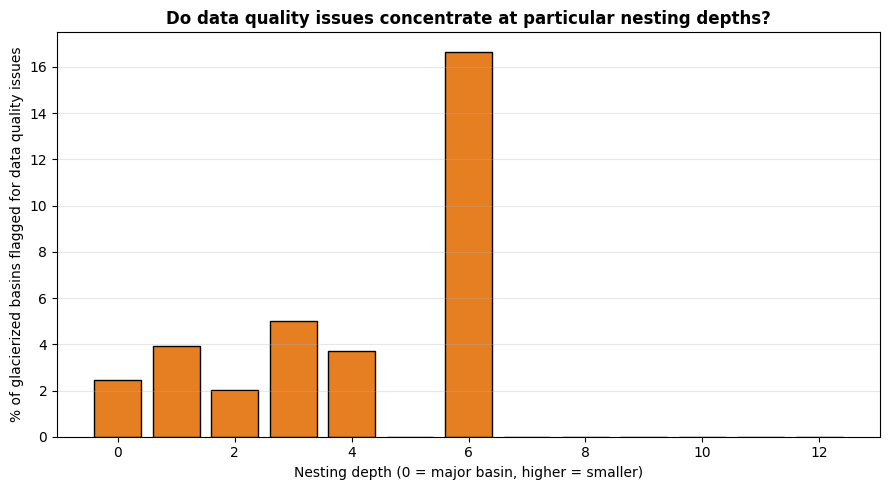

In [8]:
# ── Do data quality issues concentrate at particular nesting depths? ───────
depth_reliability = []
for depth_level in sorted(df_hierarchy['depth'].unique()):
    basins_at_depth = set(df_hierarchy[df_hierarchy['depth']==depth_level]['gauge_id'])
    glacierized_at_depth = basins_at_depth & all_glacierized_basins_ever
    flagged_at_depth = glacierized_at_depth & flagged_basins
    n_glac = len(glacierized_at_depth)
    n_flagged = len(flagged_at_depth)
    depth_reliability.append({
        'depth': depth_level, 'n_basins_total': len(basins_at_depth),
        'n_glacierized': n_glac, 'n_flagged': n_flagged,
        'pct_flagged': (n_flagged/n_glac*100) if n_glac > 0 else np.nan,
    })

df_depth_reliability = pd.DataFrame(depth_reliability)
print('Data quality reliability by nesting depth:')
print(df_depth_reliability.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
valid = df_depth_reliability.dropna(subset=['pct_flagged'])
ax.bar(valid['depth'], valid['pct_flagged'], color='#e67e22', edgecolor='k')
ax.set_xlabel('Nesting depth (0 = major basin, higher = smaller)', fontsize=10)
ax.set_ylabel('% of glacierized basins flagged for data quality issues', fontsize=10)
ax.set_title('Do data quality issues concentrate at particular nesting depths?',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_ROOT}/reliability_by_depth.png', dpi=150, bbox_inches='tight')
plt.show()


### Anomalous gauge investigation: Maipo system

Maipo's leaf-summed glacier fraction occasionally exceeded 100% (up to 555%
in one month) when combining the three leaf-level gauges feeding it. Traced
to two specific gauges — Rio Volcan En Queltehues (`5702001`) and Rio
Olivares Antes Junta Rio Colorado (`5706001`) — where simulated glacier
runoff exceeds measured streamflow **at that single gauge** (no
basin-summing involved) in a large fraction of months, **consistently
across all 3 climate datasets** (ruling out a melt-simulation artifact tied
to one dataset specifically). Estero Yerba Loca (`5721001`), the third
Maipo-system leaf gauge, shows no such issue (0 of 223 months over 100%).

**Conclusion:** the CAMELS streamflow records at these two gauges are
suspect, not the glacier melt simulation. Flagged for Alexis to review the
raw Q record at these two gauges specifically — status: pending.

In [9]:
for gid in ['5702001', '5706001', '5721001']:
    for ds in ['CR2MET', 'ERA5', 'CRU']:
        res = RESULTS[ds].get(gid)
        if res is None:
            continue
        m = res['monthly'].copy()
        m = m[m['q_m3_mon'] > 0]
        m['frac_pct'] = m['glacier_runoff_m3'] / m['q_m3_mon'] * 100
        n_over_100 = (m['frac_pct'] > 100).sum()
        print(f'{gid} / {ds}: {n_over_100} of {len(m)} months over 100%, '
              f'median={m["frac_pct"].median():.1f}%')

# Manual exclusion pending Alexis's review of the raw Q record
MANUALLY_EXCLUDED_GAUGES = {'5702001', '5706001'}
leaf_ids_final_clean = leaf_glacierized_ids_v3 - MANUALLY_EXCLUDED_GAUGES
print(f'\nLeaf basins before exclusion: {len(leaf_glacierized_ids_v3)}')
print(f'Leaf basins after excluding flagged gauges: {len(leaf_ids_final_clean)}')
print('STATUS: pending Alexis review of raw Q record at 5702001 and 5706001')


5702001 / CR2MET: 41 of 224 months over 100%, median=37.9%
5702001 / ERA5: 40 of 224 months over 100%, median=0.3%
5702001 / CRU: 25 of 224 months over 100%, median=20.0%
5706001 / CR2MET: 59 of 222 months over 100%, median=6.6%
5706001 / ERA5: 55 of 222 months over 100%, median=0.0%
5706001 / CRU: 59 of 222 months over 100%, median=0.9%
5721001 / CR2MET: 0 of 223 months over 100%, median=3.3%
5721001 / ERA5: 1 of 223 months over 100%, median=0.0%
5721001 / CRU: 0 of 223 months over 100%, median=0.0%

Leaf basins before exclusion: 103
Leaf basins after excluding flagged gauges: 101
STATUS: pending Alexis review of raw Q record at 5702001 and 5706001


## 5. Dilution visualization: glacier fraction vs. position in hierarchy

In [10]:
def basin_fraction(gid, dataset='CR2MET', months=None):
    res = RESULTS[dataset].get(gid)
    if res is None:
        return np.nan
    m = res['monthly'].copy()
    if months is not None:
        m = m[m['month'].isin(months)]
    m = m[m['q_m3_mon'] > 0].dropna(subset=['glacier_runoff_m3','q_m3_mon'])
    if len(m) == 0:
        return np.nan
    return (m['glacier_runoff_m3'].sum() / m['q_m3_mon'].sum()) * 100

chain_records = []
for leaf_gid in leaf_glacierized_ids_v3:
    if leaf_gid not in RESULTS['CR2MET']:
        continue
    chain = get_full_chain(leaf_gid, container_map, area_by_id)
    n_levels = len(chain)
    for depth_idx, gid in enumerate(chain):
        row = bounds_all[bounds_all['gauge_id']==gid]
        if len(row) == 0:
            continue
        chain_records.append({
            'leaf_gauge_id': leaf_gid,
            'chain_position': depth_idx, 'chain_length': n_levels,
            'gauge_id': gid, 'area_km2': row['area_km2'].values[0],
            'annual_fraction_pct': basin_fraction(gid),
            'leaf_flagged': leaf_gid in flagged_basins,
        })

df_chains = pd.DataFrame(chain_records)
df_chains['normalized_position'] = df_chains.apply(
    lambda row: row['chain_position']/(row['chain_length']-1) if row['chain_length']>1 else 0, axis=1)
df_chains.to_csv(f'{OUTPUT_ROOT}/basin_chain_fractions.csv', index=False)

n_nan = df_chains['annual_fraction_pct'].isna().sum()
print(f'Chain records built: {len(df_chains)} across {len(leaf_glacierized_ids_v3)} leaf chains')
print(f'NaN fraction (basin not in RESULTS -- non-glacierized pass-through basin never simulated): '
      f'{n_nan} of {len(df_chains)} ({n_nan/len(df_chains)*100:.1f}%)')


Chain records built: 239 across 103 leaf chains
NaN fraction (basin not in RESULTS -- non-glacierized pass-through basin never simulated): 72 of 239 (30.1%)


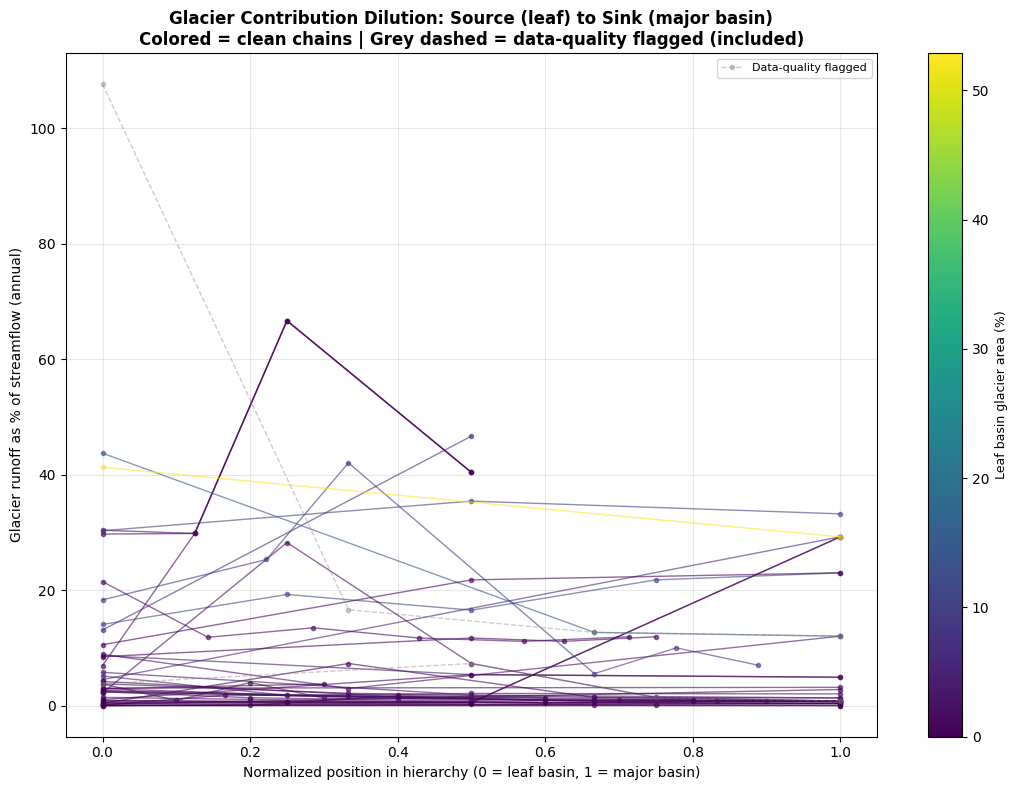

In [11]:
fig, ax = plt.subplots(figsize=(11, 8))

clean_chains = df_chains[~df_chains['leaf_flagged']]
flagged_chains = df_chains[df_chains['leaf_flagged']]

leaf_glacier_pct = {
    gid: glacier_area_by_gauge.get(gid, 0) /
         bounds_all[bounds_all['gauge_id']==gid]['area_km2'].values[0] * 100
    for gid in leaf_glacierized_ids_v3
    if len(bounds_all[bounds_all['gauge_id']==gid]) > 0
}
max_pct = max(leaf_glacier_pct.values()) if leaf_glacier_pct else 1
cmap = plt.cm.viridis
norm = Normalize(vmin=0, vmax=max_pct)

for leaf_gid in clean_chains['leaf_gauge_id'].unique():
    sub = clean_chains[clean_chains['leaf_gauge_id']==leaf_gid].sort_values('normalized_position')
    sub = sub.dropna(subset=['annual_fraction_pct'])
    if len(sub) < 2:
        continue
    color = cmap(norm(leaf_glacier_pct.get(leaf_gid, 0)))
    ax.plot(sub['normalized_position'], sub['annual_fraction_pct'],
           'o-', color=color, alpha=0.6, lw=1, ms=3)

first_flagged = True
for leaf_gid in flagged_chains['leaf_gauge_id'].unique():
    sub = df_chains[df_chains['leaf_gauge_id']==leaf_gid].sort_values('normalized_position')
    sub = sub.dropna(subset=['annual_fraction_pct'])
    if len(sub) < 2:
        continue
    ax.plot(sub['normalized_position'], sub['annual_fraction_pct'],
           'o--', color='grey', alpha=0.4, lw=1, ms=3,
           label='Data-quality flagged' if first_flagged else None)
    first_flagged = False

sm = ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Leaf basin glacier area (%)', fontsize=9)

ax.set_xlabel('Normalized position in hierarchy (0 = leaf basin, 1 = major basin)', fontsize=10)
ax.set_ylabel('Glacier runoff as % of streamflow (annual)', fontsize=10)
ax.set_title('Glacier Contribution Dilution: Source (leaf) to Sink (major basin)\n'
             'Colored = clean chains | Grey dashed = data-quality flagged (included)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_ROOT}/dilution_normalized.png', dpi=150, bbox_inches='tight')
plt.show()


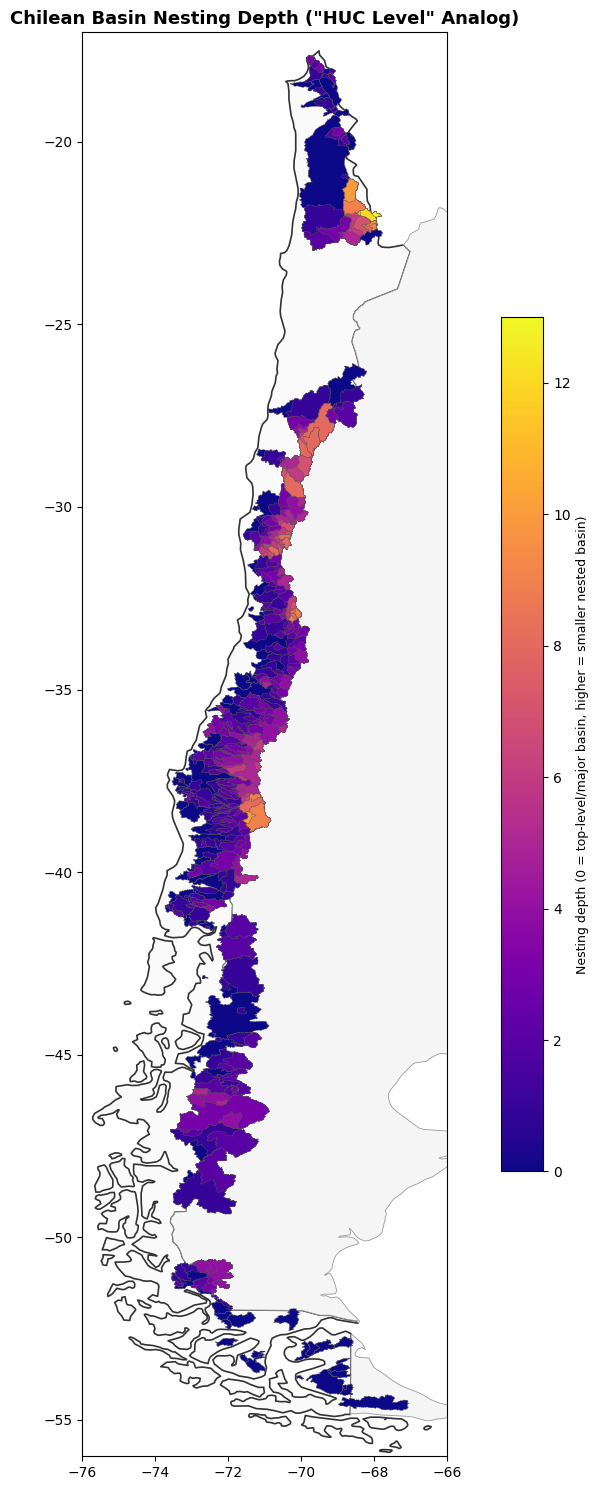

In [12]:
# ── Map: nesting depth across Chile ("HUC level" analog) ────────────────────
fig, ax = plt.subplots(figsize=(11, 15))
if has_borders:
    chile.plot(ax=ax, facecolor='#fafafa', edgecolor='#333333', linewidth=1.2, zorder=0)
    arg.plot(ax=ax, facecolor='#f5f5f5', edgecolor='#999999', linewidth=0.6, zorder=0)

bounds_depth = bounds_all.merge(df_hierarchy[['gauge_id','depth']], on='gauge_id', how='left')
bounds_depth = bounds_depth.sort_values('area_km2', ascending=False)

max_depth = bounds_depth['depth'].max()
depth_norm = Normalize(vmin=0, vmax=max_depth)
depth_cmap = plt.cm.plasma
bounds_depth.plot(ax=ax, column='depth', cmap=depth_cmap, norm=depth_norm,
                  edgecolor='#555555', linewidth=0.2, zorder=2)

sm = ScalarMappable(cmap=depth_cmap, norm=depth_norm)
cbar = fig.colorbar(sm, ax=ax, shrink=0.6)
cbar.set_label('Nesting depth (0 = top-level/major basin, higher = smaller nested basin)', fontsize=9)

ax.set_xlim(-76, -66); ax.set_ylim(-56, -17); ax.set_aspect('equal')
ax.set_title('Chilean Basin Nesting Depth ("HUC Level" Analog)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_ROOT}/nesting_depth_map.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Leaf-summed glacier fraction per major basin (annual / JFM / megadrought)

In [13]:
def compute_leaf_fraction(major_id, leaf_ids_set, months=None, years=None):
    """Sum glacier runoff and streamflow across the leaf-level glacierized
    sub-basins within major_id (NOT the major basin's own Q). A month is only
    included if ALL contributing leaf gauges have valid, non-negative Q that
    month, so the combined total is consistent across time."""
    nested_ids = contained_map.get(major_id, [])
    leaf_ids_in_major = [nid for nid in nested_ids if nid in leaf_ids_set]
    if major_id in leaf_ids_set:
        leaf_ids_in_major.append(major_id)
    if not leaf_ids_in_major:
        return np.nan, 0

    glac_frames, q_frames = [], []
    for leaf_id in leaf_ids_in_major:
        res = RESULTS['CR2MET'].get(leaf_id)
        if res is None:
            continue
        m = res['monthly'].copy()
        if years is not None:
            m = m[m['year'].isin(years)]
        if months is not None:
            m = m[m['month'].isin(months)]
        m = m.set_index(['year','month'])
        glac_frames.append(m[['glacier_runoff_m3']].rename(
            columns={'glacier_runoff_m3': f'glac_{leaf_id}'}))
        q_frames.append(m[['q_m3_mon']].rename(
            columns={'q_m3_mon': f'q_{leaf_id}'}))

    if not glac_frames:
        return np.nan, 0

    glac_wide = pd.concat(glac_frames, axis=1)
    q_wide = pd.concat(q_frames, axis=1)
    q_complete_mask = q_wide.notna().all(axis=1) & (q_wide >= 0).all(axis=1)

    q_summed = q_wide[q_complete_mask].sum(axis=1)
    glac_summed = glac_wide[q_complete_mask].sum(axis=1)

    valid = q_summed > 0
    if valid.sum() == 0:
        return np.nan, 0

    frac = (glac_summed[valid].sum() / q_summed[valid].sum()) * 100
    return frac, len(leaf_ids_in_major)

JFM_MONTHS = [1, 2, 3]
MEGADROUGHT_YEARS = list(range(2010, 2020))

scope_results = {}
for _, major_row in df_glacierized_major.iterrows():
    mid = major_row['gauge_id']
    frac_annual, n_leaf = compute_leaf_fraction(mid, leaf_ids_final_clean, months=None, years=None)
    frac_jfm, _ = compute_leaf_fraction(mid, leaf_ids_final_clean, months=JFM_MONTHS, years=None)
    frac_drought, _ = compute_leaf_fraction(mid, leaf_ids_final_clean, months=None, years=MEGADROUGHT_YEARS)
    scope_results[mid] = {'annual_pct': frac_annual, 'jfm_pct': frac_jfm,
                           'drought_pct': frac_drought, 'n_leaf': n_leaf}

n_with_result = sum(1 for r in scope_results.values() if not np.isnan(r['annual_pct']))
print(f'scope_results built for {len(scope_results)} major basins')
print(f'Major basins with a computed annual glacier fraction: {n_with_result} of {len(df_glacierized_major)}')
print('(remainder lack any completeness-passing leaf basin)')

df_scope = pd.DataFrame(scope_results).T
df_scope.index.name = 'gauge_id'
df_scope = df_scope.reset_index().merge(
    df_glacierized_major[['gauge_id','gauge_name','area_km2']], on='gauge_id', how='left')
df_scope.to_csv(f'{OUTPUT_ROOT}/major_basin_leaf_summed_fractions.csv', index=False)
print(f'Saved: {OUTPUT_ROOT}/major_basin_leaf_summed_fractions.csv')
print(df_scope.sort_values('annual_pct', ascending=False).head(10).to_string(index=False))


scope_results built for 41 major basins
Major basins with a computed annual glacier fraction: 29 of 41
(remainder lack any completeness-passing leaf basin)
Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/major_basin_leaf_summed_fractions.csv
gauge_id  annual_pct   jfm_pct  drought_pct  n_leaf                            gauge_name     area_km2
11711000   30.298306 51.442296    31.723490     1.0      Rio Pascua Ante Junta Rio Quetru 14121.323846
12289001   28.419715 27.740072    28.350342     7.0          Rio Serrano En Desembocadura  8574.609649
 3453001   25.042433 74.766019    36.478683     3.0              Rio Copiapo En Angostura 18549.908986
 5423005   18.319143 33.644291    24.945164     3.0         Rio Aconcagua En Panamericana  5647.991589
11545000   13.734004 29.443751    12.797760     6.0                  Rio Baker Bajo ÑAdis 27402.563558
 3826001   13.713061 36.075007    17.900064     2.0             Rio Huasco En Huasco Bajo  9739.814913
 5748001    8.888796 17.358

### Candidate intermediate sub-basins ("El Manzano tier")

Nested basins that themselves aggregate 2+ smaller basins (e.g. El Manzano
sits between Cabimbao and the Maipo system's leaves). Exported for Alexis
to confirm which represent recognized hydrological sub-basins vs. incidental
nested gauges.

In [14]:
intermediate_candidates = []
for _, major_row in df_glacierized_major.iterrows():
    major_id = major_row['gauge_id']
    nested_ids = contained_map.get(major_id, [])
    for nid in nested_ids:
        n_children = len(contained_map.get(nid, []))
        if n_children >= 2:
            glac_area = glacier_area_by_gauge.get(nid, 0)
            if glac_area > 0:
                name_row = bounds_all[bounds_all['gauge_id']==nid]
                if len(name_row) == 0:
                    continue
                intermediate_candidates.append({
                    'major_id': major_id, 'major_name': major_row['gauge_name'],
                    'candidate_id': nid, 'candidate_name': name_row['gauge_name'].values[0],
                    'n_children': n_children, 'glacier_area_km2': glac_area,
                })

df_intermediate = pd.DataFrame(intermediate_candidates)
print(f'Candidate intermediate sub-basin gauges found: {len(df_intermediate)}')

export_path = f'{OUTPUT_ROOT}/intermediate_subbasin_candidates_for_Ale.csv'
df_intermediate.sort_values(['major_id','n_children'], ascending=[True,False]).to_csv(
    export_path, index=False)
print(f'Saved: {export_path}')


Candidate intermediate sub-basin gauges found: 104
Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/intermediate_subbasin_candidates_for_Ale.csv


## 7. Deliverables for Alexis

### 7a. `main_basins_for_alexis.shp` export

Implements Alexis's workflow, now using `basin_hierarchy_utils` instead of
the unreliable `Camels_jerarquia.shp` field:
- Step 1: Find CAMELS polygons that contain at least one RGI glacier centroid
- Step 2: Keep only geometrically top-level (depth=0) basins per river system
- Step 3: (Visual check in QGIS/ArcGIS — do manually after export)
- Step 4: Compute basin area and glacier area, apply 1% minimum threshold

In [15]:
OUT_PATH_ALE = f'{OUTPUT_ROOT}/main_basins_for_alexis.shp'
GLAC_THRESHOLD_PCT = 1.0  # Alexis recommends 1% minimum glacier cover

joined = gpd.sjoin(gdf_rgi, bounds_all, how='inner', predicate='within')
glacierized_gauge_ids_export = set(joined['gauge_id'].unique())
glacier_stats = (joined.groupby('gauge_id')
                 .agg(n_glaciers=('RGIId','count'), glacier_area=('Area','sum'),
                      clusters=('Cluster', lambda x: list(x.unique())))
                 .reset_index())

main_basins_export = bounds_all[bounds_all['gauge_id'].isin(
    df_hierarchy[df_hierarchy['depth']==0]['gauge_id'])].copy()
main_glacierized_export = main_basins_export[
    main_basins_export['gauge_id'].isin(glacierized_gauge_ids_export)].copy()
main_glacierized_export = main_glacierized_export.merge(
    df_hierarchy[['gauge_id','depth']], on='gauge_id', how='left')

main_utm_export = main_glacierized_export.to_crs(epsg=32719)
main_utm_export['basin_area_km2'] = main_utm_export.geometry.area / 1e6
main_utm_export = main_utm_export.merge(glacier_stats, on='gauge_id', how='left')
main_utm_export['glacier_area_km2'] = main_utm_export['glacier_area'].fillna(0)
main_utm_export['glacier_pct'] = (main_utm_export['glacier_area_km2'] /
                                   main_utm_export['basin_area_km2'] * 100)

before = len(main_utm_export)
main_final = main_utm_export[main_utm_export['glacier_pct'] >= GLAC_THRESHOLD_PCT].copy()
after = len(main_final)
print(f'Geometrically top-level basins with glaciers: {before}')
print(f'After {GLAC_THRESHOLD_PCT}% threshold: {after} ({before-after} removed)')

main_export = main_final.to_crs(epsg=4326)
keep_cols = ['gauge_id','gauge_name','depth','n_glaciers','basin_area_km2',
             'glacier_area_km2','glacier_pct','geometry']
keep_cols = [c for c in keep_cols if c in main_export.columns]
main_export = main_export[keep_cols]
main_export.to_file(OUT_PATH_ALE)
print(f'Saved: {OUT_PATH_ALE}')
print(f'Total glacier area: {main_final["glacier_area_km2"].sum():.1f} km2')
print(f'Total basin area:   {main_final["basin_area_km2"].sum():.1f} km2')


Geometrically top-level basins with glaciers: 41
After 1.0% threshold: 15 (26 removed)
Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/main_basins_for_alexis.shp
Total glacier area: 6859.2 km2
Total basin area:   130359.3 km2


### 7b. Visual check of `main_basins_for_alexis.shp`

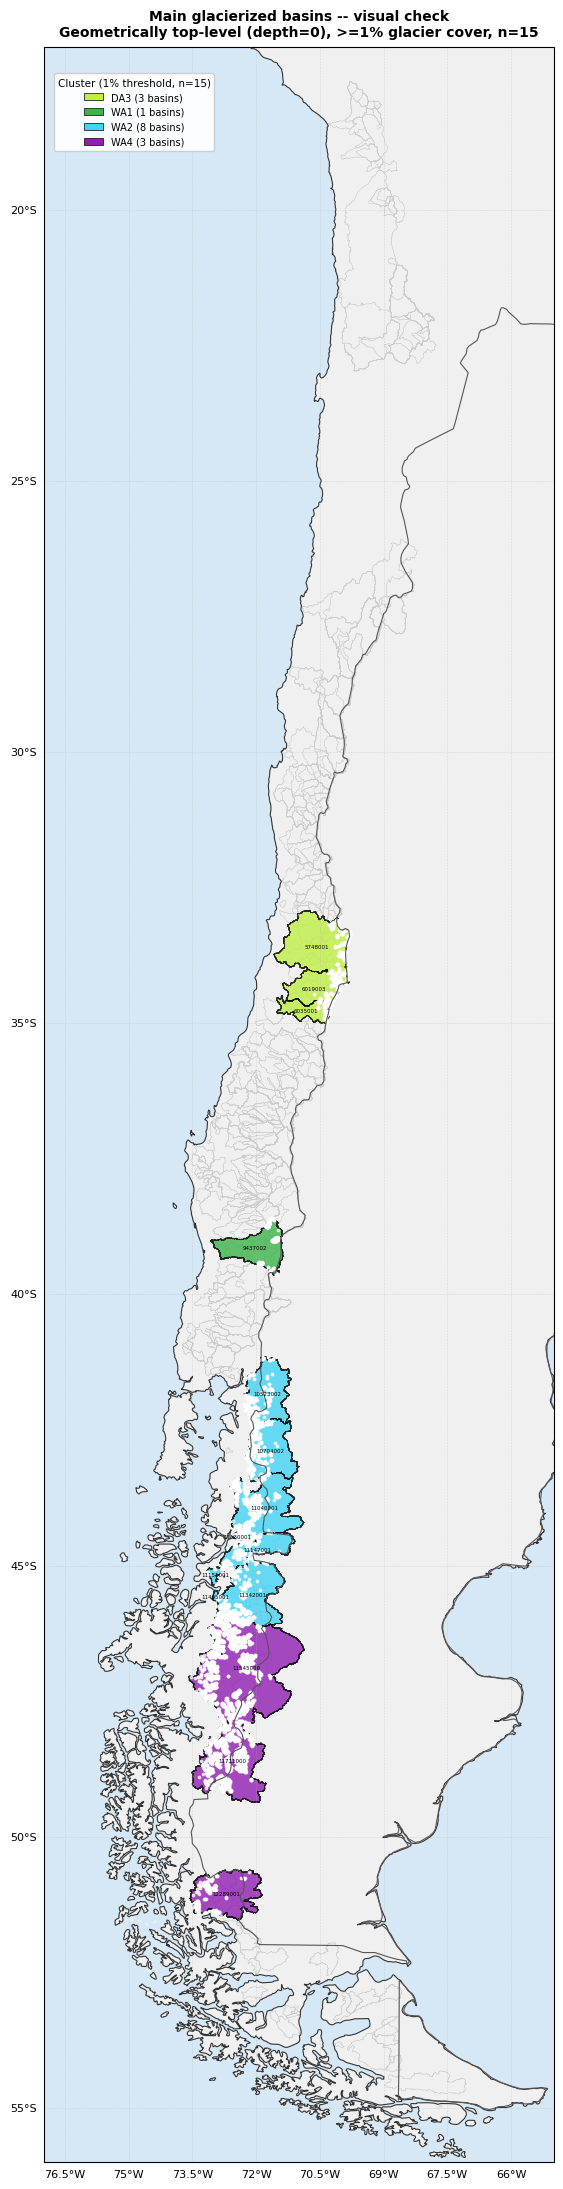

Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/main_basins_visual_check.png


In [16]:
main_check = gpd.read_file(OUT_PATH_ALE)
if main_check.crs.to_epsg() != 4326:
    main_check = main_check.to_crs(epsg=4326)

joined_check = gpd.sjoin(gdf_rgi[['RGIId','Cluster','geometry']],
                         main_check[['gauge_id','geometry']], how='inner', predicate='within')
dominant_cluster = (joined_check.groupby('gauge_id')['Cluster']
                    .agg(lambda x: x.value_counts().index[0]).reset_index()
                    .rename(columns={'Cluster':'cluster'}))
main_check = main_check.merge(dominant_cluster, on='gauge_id', how='left')

cluster_colors = {
    'OT3': '#e6194b', 'DA1': '#f58231', 'DA2': '#ffe119', 'DA3': '#bfef45',
    'WA1': '#3cb44b', 'WA2': '#42d4f4', 'WA3': '#4363d8', 'WA4': '#911eb4',
    'WA5': '#f032e6', 'WA6': '#01665e',
}

fig = plt.figure(figsize=(10, 22))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-77, -65, -56, -17], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.OCEAN, facecolor='#d6e8f5', zorder=0)
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', zorder=0)
bounds_all.plot(ax=ax, facecolor='none', edgecolor='#cccccc', linewidth=0.3, zorder=1)

for cl, color in cluster_colors.items():
    subset = main_check[main_check['cluster']==cl]
    if len(subset):
        subset.plot(ax=ax, facecolor=color, edgecolor='k', linewidth=0.6, alpha=0.8, zorder=2)
unassigned = main_check[main_check['cluster'].isna()]
if len(unassigned):
    unassigned.plot(ax=ax, facecolor='#cccccc', edgecolor='k', linewidth=0.4, alpha=0.6, zorder=2)

glaciers_in = gpd.sjoin(gdf_rgi, main_check[['gauge_id','geometry']], how='inner', predicate='within')
ax.scatter(glaciers_in.CenLon, glaciers_in.CenLat, s=3, c='white', alpha=0.7, zorder=3,
           transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#333333', zorder=4)
if has_borders:
    arg.plot(ax=ax, facecolor='none', edgecolor='#555555', linewidth=0.8, zorder=4,
             transform=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.4, linestyle='--')
gl.top_labels = False; gl.right_labels = False
gl.xlabel_style = {'size': 8}; gl.ylabel_style = {'size': 8}

# NOTE: shapefile field names truncate to 10 chars, so 'gauge_name' becomes
# 'gauge_nam' on disk -- unrelated to the jerarquia fix, pre-existing behavior
for _, row in main_check.iterrows():
    centroid = row.geometry.centroid
    name = str(row.get('gauge_nam', row['gauge_id']))[:18]
    ax.text(centroid.x, centroid.y, name, fontsize=4, ha='center', va='center',
            color='k', zorder=5, transform=ccrs.PlateCarree())

legend_handles = []
for cl in cluster_colors:
    n = (main_check['cluster']==cl).sum()
    if n:
        legend_handles.append(Patch(facecolor=cluster_colors[cl], edgecolor='k',
                                     linewidth=0.5, label=f'{cl} ({n} basins)'))
ax.legend(handles=legend_handles, loc='upper left', fontsize=7, framealpha=0.93,
          title=f'Cluster (1% threshold, n={len(main_check)})', title_fontsize=7.5,
          bbox_to_anchor=(0.01,0.99))
ax.set_title(f'Main glacierized basins -- visual check\n'
             f'Geometrically top-level (depth=0), >=1% glacier cover, n={len(main_check)}',
             fontsize=10, fontweight='bold', pad=8)
plt.tight_layout()
out = f'{OUTPUT_ROOT}/main_basins_visual_check.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


### 7c. Major-basin map with glacier-fraction pie-chart pullouts

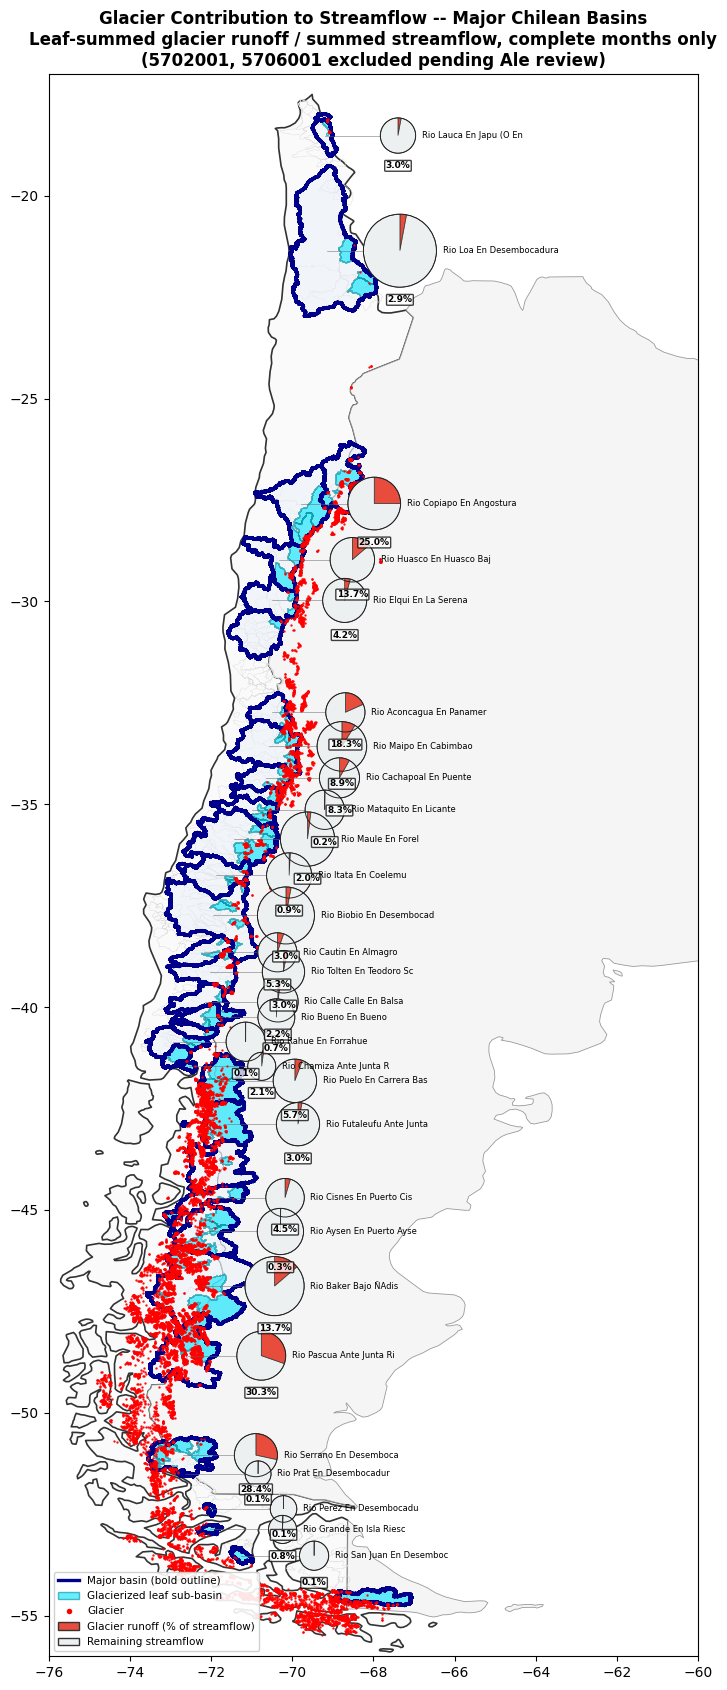

In [17]:
fig, ax = plt.subplots(figsize=(13, 17))
if has_borders:
    chile.plot(ax=ax, facecolor='#fafafa', edgecolor='#333333', linewidth=1.2, zorder=0)
    arg.plot(ax=ax, facecolor='#f5f5f5', edgecolor='#999999', linewidth=0.6, zorder=0)

bounds_all.plot(ax=ax, facecolor='none', edgecolor='#dddddd', linewidth=0.2, zorder=1)

glacierized_ids = set(df_glacierized_major['gauge_id'])
bounds_all[bounds_all['gauge_id'].isin(glacierized_ids)].plot(
    ax=ax, facecolor='#eaf2fa', alpha=0.5, edgecolor='none', zorder=2)
bounds_all[bounds_all['gauge_id'].isin(glacierized_ids)].plot(
    ax=ax, facecolor='none', edgecolor='#00008b', linewidth=2.4, zorder=4)
bounds_all[bounds_all['gauge_id'].isin(leaf_glacierized_ids_v3)].plot(
    ax=ax, facecolor='#00e5ff', alpha=0.6, edgecolor='#008b99', linewidth=0.7, zorder=3)

glacier_centroids_proj = rgi_geoms_combined.to_crs(epsg=32719).geometry.centroid
glacier_centroids = gpd.GeoSeries(glacier_centroids_proj, crs=32719).to_crs(epsg=4326)
ax.scatter(glacier_centroids.x, glacier_centroids.y, color='#ff0000', s=0.5, zorder=5, alpha=0.9)

has_scope = [g for g, r in scope_results.items() if not np.isnan(r['annual_pct'])]
df_pie = df_glacierized_major[df_glacierized_major['gauge_id'].isin(has_scope)].copy()
df_pie['centroid'] = df_pie['gauge_id'].apply(
    lambda g: bounds_all[bounds_all['gauge_id']==g].geometry.centroid.values[0]
    if len(bounds_all[bounds_all['gauge_id']==g]) else None)
df_pie = df_pie[df_pie['centroid'].notna()]
df_pie['cen_lat'] = df_pie['centroid'].apply(lambda c: c.y)
df_pie['frac_pct'] = df_pie['gauge_id'].map(lambda g: scope_results[g]['annual_pct'])

area_max = df_pie['area_km2'].max()
CIRC_MAX, CIRC_MIN = 0.9, 0.28
def area_to_radius(area):
    return CIRC_MIN if area <= 0 else CIRC_MIN + (area/area_max)**0.5 * (CIRC_MAX-CIRC_MIN)

LABEL_OFFSET = 1.8
for _, row in df_pie.sort_values('cen_lat', ascending=False).iterrows():
    cx, cy = row['centroid'].x, row['centroid'].y
    label_x = cx + LABEL_OFFSET
    radius = area_to_radius(row['area_km2'])
    frac = row['frac_pct']
    ax.plot([cx, label_x], [cy, cy], color='#666666', lw=0.5, zorder=6, alpha=0.7)
    frac_clip = min(frac/100, 1.0)
    theta1 = 90
    for size, fc in [(frac_clip, '#e74c3c'), (1-frac_clip, '#ecf0f1')]:
        theta2 = theta1 - size*360
        ax.add_patch(Wedge((label_x, cy), radius, min(theta1,theta2), max(theta1,theta2),
                    facecolor=fc, edgecolor='#333333', lw=0.5, zorder=7))
        theta1 = theta2
    ax.add_patch(plt.Circle((label_x, cy), radius, facecolor='none',
                edgecolor='#222222', lw=0.7, zorder=8))
    ax.text(label_x, cy-radius-0.2, f'{frac:.1f}%', ha='center', va='top', fontsize=6.5,
            fontweight='bold', zorder=9,
            bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.75))
    ax.text(label_x+radius+0.15, cy, row['gauge_name'][:24], fontsize=6, va='center',
            ha='left', zorder=9)

legend_elements = [
    Line2D([0],[0], color='#00008b', lw=2.4, label='Major basin (bold outline)'),
    Patch(facecolor='#00e5ff', edgecolor='#008b99', alpha=0.6, label='Glacierized leaf sub-basin'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#ff0000', markersize=5, label='Glacier'),
    Patch(facecolor='#e74c3c', edgecolor='#333333', label='Glacier runoff (% of streamflow)'),
    Patch(facecolor='#ecf0f1', edgecolor='#333333', label='Remaining streamflow'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=7.5, framealpha=0.9)
ax.set_title('Glacier Contribution to Streamflow -- Major Chilean Basins\n'
             'Leaf-summed glacier runoff / summed streamflow, complete months only\n'
             '(5702001, 5706001 excluded pending Ale review)',
             fontsize=12, fontweight='bold')
ax.set_xlim(-76, -60); ax.set_ylim(-56, -17); ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(f'{OUTPUT_ROOT}/major_basins_pie_glacier_fraction_for_Ale.png',
            dpi=200, bbox_inches='tight')
plt.show()


## Status / open items for Alexis

- Confirm whether the `jerarquia` field in `Camels_jerarquia.shp` was ever
  meant to be populated with real hierarchy levels, or is a placeholder from
  the original ArcGIS export (email sent).
- Review the raw CAMELS Q record at gauges `5702001` (Rio Volcan En
  Queltehues) and `5706001` (Rio Olivares Antes Junta Rio Colorado) —
  glacier runoff exceeds measured streamflow in a large fraction of months
  at each gauge individually, consistently across CR2MET/ERA5/CRU,
  suggesting a streamflow record issue rather than a melt-simulation issue.
- Confirm which rows in `intermediate_subbasin_candidates_for_Ale.csv`
  represent recognized hydrological sub-basins (the "El Manzano tier") vs.
  incidental nested gauges.
- Decide whether a minimum glacier-area-to-basin-area threshold should be
  applied to `leaf_glacierized_ids_v3` for consistency with the main
  sub-basin analysis (which uses 0.1%) — currently unfiltered here.
